In [2]:
import numpy as np
import numpy.typing as npt

## 1. Vector Operations on Embeddings
In class we learned about the classic word embedding example of the relationship between the concepts queen, king, women and man. 

For this problem you will work with dummy vector encodings in numpy to work through this concept in code.

Given the below vector encodings of queen, women, and man create a vector encoding the concept of royalty and king.

*Note: You must use vector operation on the existing vectors to create the new vectors*

For 5 point extra credit create a 3D-plot showing the relationship between these vectors. These points will be added to your intial attempt and must be included in the intial attempt to recieve credit since you will likely get the solution in class.

In [2]:
import numpy as np

queen = np.array([5, 6, 4])
women = np.array([1, 3, 2])
man = np.array([5, 5, 5])
royalty = None
king = None

# In the classic analogy queen = royaly + female 
# This means royalty = queen - female (women) 
royalty = queen - women 

# Then king = royalty + male (man)
king = royalty + man

print("royalty:", royalty)
print("king:", king)

royalty: [4 3 2]
king: [9 8 7]


## 2. Vector Magnitude
In class we learned the formula for vector magintude. 

Create your own implimentation of `vector_magnitude` not using `numpy.linalg.norm` but instead using vector operations in numpy. Use the test and example vectors to check your solution. 

In [6]:
import numpy.typing as npt

def vector_magnitude(np_vector: npt.NDArray) -> np.float64:
    # Square each number in the vector 
    squared = np_vector ** 2

    # Sum all squared values 
    summed = np.sum(squared)

    # Take the square root to get mangnitude
    magnitude = np.sqrt(summed)
    return magnitude

def test_vector_magnitude(np_vector: npt.NDArray) -> None:
    if vector_magnitude(np_vector) == np.linalg.norm(np_vector):
        print(f"Test passed for {np_vector}")
    else:
        print(f"Test failed for {np_vector}")


d1_vector = np.array([5])
d2_vector = np.array([3.2, 0.1])
d3_vector = np.array([-2, 2, 2])
d10_vector = np.random.randint(100, size=(10))

test_vector_magnitude(d1_vector)
test_vector_magnitude(d2_vector)
test_vector_magnitude(d3_vector)
test_vector_magnitude(d10_vector)

Test passed for [5]
Test passed for [3.2 0.1]
Test passed for [-2  2  2]
Test passed for [15 29 80 69 35 76 69 40 60  0]


## 3. Unit Vectors
Using your implimentation of `vector_magnitude` above create a function `create_unit_vector` which creates a unit vector from a `np.array`. Create another function `test_create_unit_vector` following the pattern in `test_vector_magnitude` that tests the static vectors above with the corrisponding unit vectors defined below.

Hint: Use np.allclose instead of == . Explain why this is needed.

In [ ]:
d1_unit_vector = np.array([1.])
d2_unit_vector = np.array([0.99951208, 0.03123475])
d3_unit_vector = np.array([-0.57735027,  0.57735027,  0.57735027])

#Impliment vector_magnitude and test_vector_magnitude here
def create_unit_vector(np_vector: npt.NDArray) -> npt.NDArray:
    # A unit vector is a vector that points in the same direction as the original vector but with a length/magnitude of 1
    # Dividing the vector by its own length shrinks or stretches it to length 1 without changing its direction
    magnitude = vector_magnitude(np_vector)

    # This keeps the direction the same, but makes the total length = 1
    unit_vector = np_vector / magnitude

    return unit_vector


def test_create_unit_vector(np_vector: npt.NDArray, expected_unit_vector: npt.NDArray) -> None:
    # Compute vector using our function
    computed_unit_vector = create_unit_vector(np_vector)

    # We use np.allclose instead of == because these are floating point numbers
    # Floating point math can create tiny rounding differences
    # == would treat that as different, but allclose treats it as close enough
    if np.allclose(computed_unit_vector, expected_unit_vector):
        print(f"Test passed for {np_vector}")
    else:
        print(f"Test failed for {np_vector}")
        print("Expected:", expected_unit_vector)
        print("Got:", computed_unit_vector)


# Run the provided tests
test_create_unit_vector(d1_vector, d1_unit_vector)
test_create_unit_vector(d2_vector, d2_unit_vector)
test_create_unit_vector(d3_vector, d3_unit_vector)


Test passed for [5]
Test passed for [3.2 0.1]
Test passed for [-2  2  2]


## 4. Dot Product
Again there exists a function in numpy that calculates the dot product formula we learrned in class, `numpy.dot`. For this problem you will write your on implimentation of the dot product using the formula from class and basic vector operations. You will alo need to create a test to compare your implimentation to `numpy.dot` and create 3 test cases that follow the guidance below.

1. The first test case should perform the dot product of a 3d vector with itself
2. The second test case should include integers and floats
3. For the third test case think of another edge case you might want to test against


In [8]:
def dot_product(vec_a: np.ndarray, vec_b: np.ndarray) -> float:
    # The dot product takes two vectors of the same length and
    # multiplies their corresponding elements together.
    # After multiplying, we add up all of those values to get
    # a single number

    # Multiply each element in vec_a by the corresponding element in vec_b
    multiplied = vec_a * vec_b

    # Sum all the multiplied values to get the final dot product
    result = np.sum(multiplied)

    return result


def test_dot_product(vec_a: np.ndarray, vec_b: np.ndarray) -> None:
    # Compute the dot product using our implementation
    my_result = dot_product(vec_a, vec_b)

    # Compute the dot product using numpy's built-in function
    numpy_result = np.dot(vec_a, vec_b)

    if np.allclose(my_result, numpy_result):
        print(f"Test passed for {vec_a} · {vec_b}")
    else:
        print(f"Test failed for {vec_a} · {vec_b}")
        print("Expected:", numpy_result)
        print("Got:", my_result)

# Test case 1: dot product of a 3D vector with itself
v1 = np.array([1, 2, 3])
test_dot_product(v1, v1)

# Test case 2: vectors containing both integers and floats
v2 = np.array([1, 2.5, -3])
v3 = np.array([4.0, -1, 2])
test_dot_product(v2, v3)

# Test case 3: edge case using the zero vector
# The dot product with a zero vector should always be 0
v4 = np.array([5, -2, 7])
zero_vector = np.array([0, 0, 0])
test_dot_product(v4, zero_vector)


Test passed for [1 2 3] · [1 2 3]
Test passed for [ 1.   2.5 -3. ] · [ 4. -1.  2.]
Test passed for [ 5 -2  7] · [0 0 0]


## 5. Predictions with dot products
Using linear regression we created the following model to predict the weight of a cat given the length and height. 

$$weight  = 0.23 * length + 1.07 * height + 3.412$$

Impliment a function `predict_weight` which will take in a 2d vector of a cat's length and height and will output the predicted weight of the cat. 

Also create a function `prediction_error` which will take the predicted weight and the actual weight of the cat and give the absolute value of the error between the two.

Use these functions to predict the weights of the cats below and figure out the error the predicted weights compared to the actual weights. Print out the results. 

In [ ]:
cat_1_array = np.array([28.57, 10.435])
cat_1_actual_weight = 24.21

cat_2_array = np.array([19.04, 6.93])
cat_2_actual_weight = 13.831

# Coefficients from the linear regression model
WEIGHTS = np.array([0.23, 1.07])

# Bias from the model
BIAS = 3.412


def predict_weight(cat_vector: np.ndarray) -> float:
    # This function predicts the weight of a cat using a linear model
    # The cat_vector contains:
    # [length, height]
    
    # Use the dot product to multiply each feature by its weight
    # and then add the bias term

    # Compute the dot product between the weights and the cat measurements
    prediction = dot_product(WEIGHTS, cat_vector)

    # Add the bias to get the final predicted weight
    predicted_weight = prediction + BIAS

    return predicted_weight


def prediction_error(predicted_weight: float, actual_weight: float) -> float:
    # This function calculates how far off the prediction is
    # from the actual weight of the cat
    
    # Using the absolute value so the error is always positive
    error = abs(predicted_weight - actual_weight)
    return error

# Cat 1 prediction
cat_1_predicted = predict_weight(cat_1_array)
cat_1_error = prediction_error(cat_1_predicted, cat_1_actual_weight)

print("Cat 1 predicted weight:", cat_1_predicted)
print("Cat 1 actual weight:", cat_1_actual_weight)
print("Cat 1 prediction error:", cat_1_error)
print()

# Cat 2 prediction
cat_2_predicted = predict_weight(cat_2_array)
cat_2_error = prediction_error(cat_2_predicted, cat_2_actual_weight)

print("Cat 2 predicted weight:", cat_2_predicted)
print("Cat 2 actual weight:", cat_2_actual_weight)
print("Cat 2 prediction error:", cat_2_error)


Cat 1 predicted weight: 21.14855
Cat 1 actual weight: 24.21
Cat 1 prediction error: 3.0614500000000007

Cat 2 predicted weight: 15.206299999999999
Cat 2 actual weight: 13.831
Cat 2 prediction error: 1.3752999999999993


## 6. Linear Weighted Combinations
In class I showed the below code for calculating linear weighted combinations. 

```
l1 = 1
l2 = 2
l3 = -3
v1 = np.array([4,5,1])
v2 = np.array([-4,0,-4])
v3 = np.array([1,3,2])
l1*v1 + l2*v2 + l3*v3
```

Rewrite this code into a function called `linear_comb_loop` that will accept as input the scalars in a list and the vectors as elements in a list. Such that:

```
scalars_array = np.array([1, 2, -3])
vectors_array = np.array([[4,5,1], [-4,0,-4], [1,3,2]])

linear_comb_loop(scalars_array, vectors_array)
```

In this function use a for loop to implement the linear weighted combination operation. Initialize the output vector using np.zeros(). Confirm that you get the same result as in the previous code.

For 5 point extra credit create a second implementation that vectorizes this solution. Run some test that will check which implementation runs faster. These points will be added to your intial attempt and must be included in the intial attempt to recieve credit since you will likely get the solution in class.


In [ ]:
import numpy as np

def linear_comb_loop(scalars_array: np.ndarray, vectors_array: np.ndarray) -> np.ndarray:
    # this function computes a linear combination
    # meaning: multiply each vector by a scalar and add them all together

    # create a zero vector that has the same shape as one input vector
    # we use this as a running total as we add scaled vectors
    output = np.zeros_like(vectors_array[0], dtype=float)

    # go through each scalar/vector pair
    for i in range(len(scalars_array)):

        # scalars_array[i] stretches or shrinks the vector
        # then we add it to the running total
        output += scalars_array[i] * vectors_array[i]

    # after the loop finishes, output is the final combined vector
    return output

# example scalars
# these control how much influence each vector has
scalars_array = np.array([1, 2, -3])

# example vectors
vectors_array = np.array([
    [4, 5, 1],
    [-4, 0, -4],
    [1, 3, 2]
])

# unpacking just makes the math easier to read
l1, l2, l3 = scalars_array
v1, v2, v3 = vectors_array

# this is the manualS numpy way without a loop
# numpy multiplies each vector and adds them automatically
original_result = l1 * v1 + l2 * v2 + l3 * v3

# now run our loop version
loop_result = linear_comb_loop(scalars_array, vectors_array)

print("original result", original_result)
print("loop result", loop_result)

# floating point math can be slightly imprecise,
# so allclose checks if the numbers are basically equal
print("matches original", np.allclose(loop_result, original_result))


## 7. Create a Basis
In this exercise, you will draw random points in subspaces. This will help reinforce the idea that subspaces comprise any linear weighted combination of the spanning vectors. Define a vector set containing one vector [1, 3]. Then create 100 numbers drawn randomly from a uniform distribution between −4 and +4. Those are your random scalars. Multiply the random scalars by the basis vector to create 100 random points in the subspace. Plot those points using `plot_vectors`.



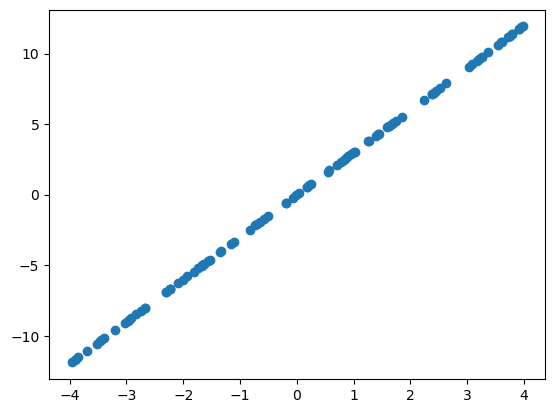

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_vectors(vectors):
    # vectors is a list/array of points like (x, y)
    # zip(*vectors) separates all x values and y values
    # scatter plots them on a graph
    plt.scatter(*zip(*vectors))
    plt.show()


# this is our basis vector
# I think of it as a direction starting at (0,0)
# move 1 unit right and 3 units up
basis_vector = np.array([1, 3])


# generate 100 random numbers between -4 and 4
# these are scalars
# scalars tell us how far to travel in the direction of the basis vector
random_scalars = np.random.uniform(-4, 4, size=100)


# reshape the scalars so numpy can multiply each scalar
# across BOTH elements of the basis vector
# this allows broadcasting to work properly
points = random_scalars[:, None] * basis_vector

# plot the generated points
plot_vectors(points)


## 8. Extra Credit (10pts): Create a 3d Basis
This problem will not be graded on the final attempt and is only extra credit on the intial attempt and one of the problems a student can present in class for their participation credit that week.
These points will be added to your intial attempt and must be included in the intial attempt to recieve credit since you will likely get the solution in class.

Next, repeat the procedure but using two vectors in 3 dimensional space: [3, 5, 1] and [0, 2, 2]. Note that you need 100 × 2 random scalars for 100 points and two vectors. The resulting random dots will be on a plane. Plot this vectors on a 3 dimensional graph.


## 9. Calculating Correlations 

Write two Python function that takes two vectors as input. The first one will calculate the Pearson correlation coefficient and the second cosine similarity value. Write code that follows the formulas presented in class; don’t simply call `np.corrcoef` and `spatial.distance.cosine`. 

Write the following tests:
1. `test_persons` which will test that your implimentation of the Pearson's correlation coefficient matches `np.corrcoef`.
2. `test_cosine` which will test that your implimentation of the cosine similarity value matches `spatial.distance.cosine`.
3. A test which will check if your implimentation of the Pearson's correlation coefficient matches your implimentation of the cosine similarity value. 


Create two test cases:
1. Mean centered vectors
2. Non-mean centered vectors

Run all three tests on the two test cases and describe what you find.

In [ ]:
def pearson_correlation_coefficient(vec_a, vec_b): 
    # Pearson correlation coefficient calculates the linear correlation between two variables (our variables are vectors)
    # first we calculate the mean of each vector 
    mean_a = np.mean(vec_a)
    mean_b = np.mean(vac_b)

    # create a numerator and denementaor to generate the function in python 
    numerator = np.sum((vec_a - mean_a) *(vec_b - mean_b))
    first_element_denomenator = np.sum((vec_a - mean_a)^2)
    second_element_denomenator = np.sum((vec_b - mean_b)^2)
    demonenator = np.sqrt((first_element_denomenator)*(second_element_denomenator))
    result = numerator / demonenator
    return result

def second_cosine_similarity_value(vec_a, vec_b):
    dot_product_result = dot_product(vec_a, vec_b)
    product_of_magnitudes = vector_magnitude(vec_a) * vector_magnitude(vec_b)
    result = dot_product_result / product_of_magnitudes
    return result

def pearson_correlation_coefficient(vec_a, vec_b):
    # Determine mean centered vector
    np.array([1, 2, 3, 4])
    
def test_dot_product(vec_a: np.ndarray, vec_b: np.ndarray) -> None:
    # Compute the dot product using our implementation
    my_result = dot_product(vec_a, vec_b)

    # Compute the dot product using numpy's built-in function
    numpy_result = np.dot(vec_a, vec_b)

    if np.allclose(my_result, numpy_result):
        print(f"Test passed for {vec_a} · {vec_b}")
    else:
        print(f"Test failed for {vec_a} · {vec_b}")
        print("Expected:", numpy_result)
        print("Got:", my_result)